# Estimating cosmological parameters and selecting cosmological models with SNIa data

We find best-fit parameters and select the best cosmological model using the [Supernova Cosmology Project](http://supernova.lbl.gov/union/) data. These consist of measurements of the distance modulus of 580 Supernovae Ia, an excellent standard candle:

$$\mu = m_B-M_B$$

with $m_B$ apparent magnitude and $M_B$ absolute magnitude in some band (e.g. the blue band, $B$). The absolute magnitude is inferred from the shape of $m_B(t)$.

The distance modulus can be related in turn to the luminosity distance, which is a function of the redshift $z$ of the source:

$$\mu(z, \boldsymbol{\theta})=5 \log_{10} \dfrac{d_{L}(z, \boldsymbol{\theta})}{\text{Mpc}}+25$$

with $d_L$ luminosity distance of the source. In the *flat* Standard Cosmological model LCDM, this is given by

$$d_{L}\left(z; h, \Omega_{m}\right)=\dfrac{c}{100\dfrac{\text{s*Mpc}}{\text{Km}} h}(1+z)
\int_{0}^{z} \frac{\mathrm{d} z^{\prime}}{\sqrt{\Omega_{m}\left(1+z^{\prime}\right)^{3}+(1-\Omega_{m})}}$$

with $h$ is the dimensionless Hubble constant and $\Omega_{m}$ the density parameter of matter. In this model Dark Energy (DE) is interpreted as a constant term ($\Lambda$) in Einstein's field equations of General Relativity.
A simple generalization of this model is to consider DE as a perfect fluid with equation of state $p=w_0\rho$, with $w_0$ the equation of state parameter (wCDM). It reduces to LCDM for $w_0 = -1$ = const. In this model the luminosity distance is

$$d_{L}\left(z; h, \Omega_{m}, w_0\right)=\dfrac{c}{100\dfrac{\text{s*Mpc}}{\text{Km}} h}(1+z)
\int_{0}^{z} \frac{\mathrm{d} z^{\prime}}{\sqrt{\Omega_{m}\left(1+z^{\prime}\right)^{3}+(1-\Omega_{m})\left(1+z^{\prime}\right)^{3(1+w_0)}}}$$

To sum up, in this excercise we'll use two models:
1.  flat LCDM model: $w_0=-1=\rm{const}$,  $\quad\boldsymbol{\theta}=(h, \Omega_{m})$
2.  flat wCDM model: variable $w_0$, $\quad \boldsymbol{\theta}=(h, \Omega_{m}, w_0)$

## Steps of the excercise:

### Parameter estimation in the frequentist approach
* best-fit values, confidence intervals, goodness of fit
### Parameter estimation in the bayesian approach
* define priors and run chains
* plot trace and posteriors; get best-fit values, credible intervals
* use a different sampler and compare the results
* compare posterior with profile likelihood XXX
* run posterior predictive checks XXX
### Model selection
* compare the models in the frequentist approach
* assess the evidence strength using Jeffreys' scale  
* compare the models the same with the SD density ratio
* compare the models in the frequentist approach
### Forecasts
* Compute numerical derivatives using different methods
* Check against analytical derivatives XXX
* Compare results against MCMC


### Imports

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import multiprocessing as mp
import corner
from astropy.cosmology import LambdaCDM
from astropy.cosmology import wCDM
from astropy import units as aq
from scipy import stats
import time
import scipy.optimize

params = {
    'lines.linewidth': 1,
    'font.size': 13,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'xtick.labelsize': 'medium',
    'ytick.labelsize': 'medium',
}
plt.rcParams.update(params)

In [26]:
root = '/Users/davidesciotti/Documents/Work/Code/Astrostats'
data_union = np.genfromtxt(f'{root}/input/SCPUnion2.1_mu_vs_z.txt')
data_union = data_union[np.argsort(data_union[:, 1])]

z_obs = data_union[:, 1]
y_obs = data_union[:, 2]
sigma_y = data_union[:, 3]
data = z_obs, y_obs, sigma_y
data_cov = np.diag(sigma_y**2)
inv_data_cov = np.linalg.inv(data_cov)
sign, ln_det_data_cov = np.linalg.slogdet(data_cov)

N_obs = z_obs.size

models = ['LCDM', 'wCDM']
c = 299792.458  # km/s

### Settings

In [27]:
prior_type = 'flat'

par_names_dict = {'LCDM': ['h', 'Om'], 'wCDM': ['h', 'Om', 'w0']}
par_names_tex_dict = {
    'LCDM': [r'$h$', r'$\Omega_m$'],
    'wCDM': [r'$h$', r'$\Omega_m$', r'$w_0$'],
}

dof_dict = {
    'LCDM': N_obs - len(par_names_dict['LCDM']),
    'wCDM': N_obs - len(par_names_dict['wCDM']),
}


prior_ranges = {
    'h': [0.50, 0.90],
    'Om': [0.0, 1.0],
    'w0': [-2.0, 0.0],
}

# slightly narrower, to speed things up
profile_ranges = {
    'h': [0.60, 0.80],
    'Om': [0.2, 1],
    'w0': [-1.5, -0.2],
}

# guess starting point to search minimum with scipy.optimize.minimize
theta_fid = {'h': 0.70, 'Om': 0.28, 'w0': -1.0}

p_val_threshold = 0.05

# emcee
Nsteps = 2000
Nwalkers = 10
burn_in_fraction = 0.2  # fraction of initial steps to discard as burn-in

# nautilus
n_live = 2000
seed = 42

### 0. Write down the model prediction (the theory) and compare to the data $d_i = (z_i, \mu(z_i))$ as a quick sanity check
* Use some resonable parameter values (e.g., h = 0.7, Om = 0.3, w = -1)
* Overplot data with error bars and model prediction
* Note: we are working with nested models, so a single function will suffice (athough this is not the most efficient approach)
* Tip: the model is quite easy to write down, but for MCMCs performance counts a lot. `astropy` has a convenient function you can use to speed things up and as a cross-check (beware of the units)
```
dl = wCDM(H0=100.0 * h, Om0=Om, Ode0=Ode, w0=w0).luminosity_distance(z)
dm = 5.0 * np.log10(dl.to(aq.Mpc) / (1.0e-5 * aq.Mpc))
```

Text(0, 0.5, '$\\mu(z)$')

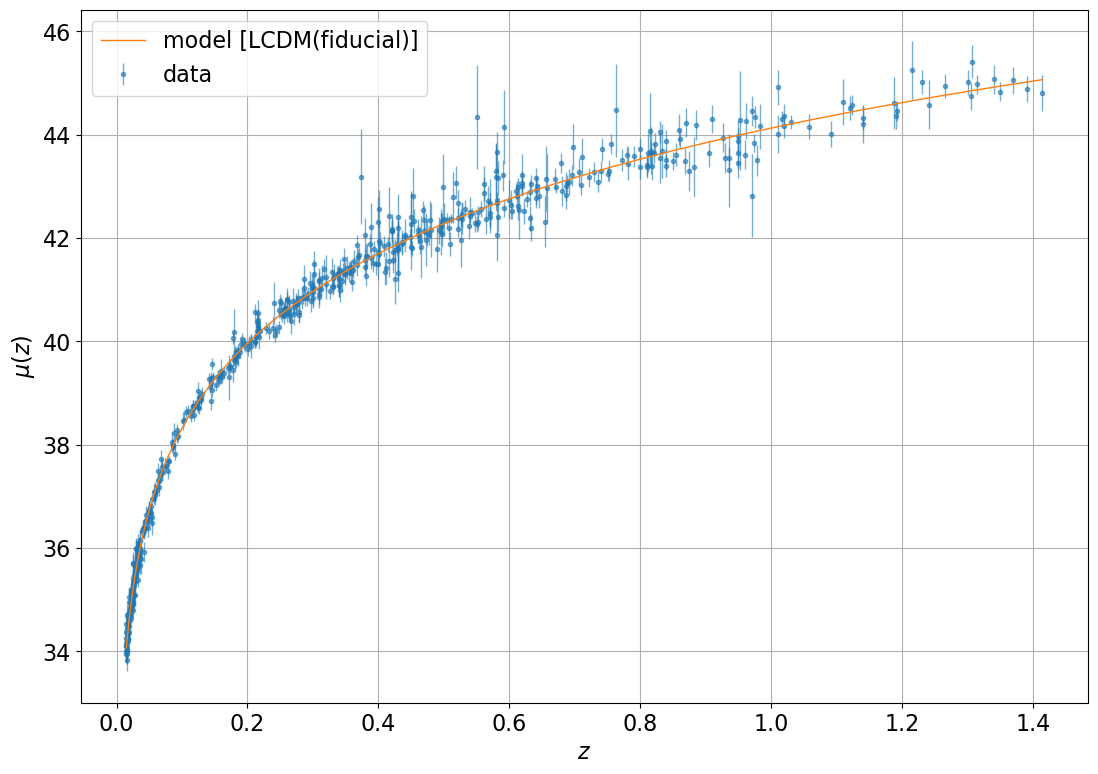

In [28]:
def model_prediction(z, theta, model):
    if model == 'LCDM':
        h, Om = theta
        Ode = 1 - Om
        dl = LambdaCDM(H0=100.0 * h, Om0=Om, Ode0=Ode).luminosity_distance(z)
    elif model == 'wCDM':
        h, Om, w0 = theta
        Ode = 1 - Om
        dl = wCDM(H0=100.0 * h, Om0=Om, Ode0=Ode, w0=w0).luminosity_distance(z)
    dm = 5.0 * np.log10(dl.to(aq.Mpc) / (1.0e-5 * aq.Mpc))
    return dm


theta_LCDM = np.array([theta_fid['h'], theta_fid['Om']], dtype=float)
plt.figure(figsize=(13, 9))
plt.tick_params(labelsize=16)
plt.errorbar(z_obs, y_obs, yerr=sigma_y, fmt='.', alpha=0.6, label='data')
plt.plot(
    np.sort(z_obs),
    model_prediction(np.sort(z_obs), theta_LCDM, 'LCDM'),
    alpha=1.0,
    label='model [LCDM(fiducial)]',
    zorder=10,
)
plt.grid()
plt.legend(prop={'size': 16})
plt.xlabel(r'$z$', fontsize=16)
plt.ylabel(r'$\mu(z)$', fontsize=16)

---

# Part 1 - Frequentist parameter inference

### Maximum Likelihood Estimation
As a starting point, let's try to estimate the best-fit parameters by maximizing the logarithm of the likelihood LL - or equivalently by minimizing the negative log likelihood, NLL. \
As seen, this has a couple issues:
- it is just a point estimate, and does not take into account the full shape of $\mathcal{L}(\boldsymbol{\theta};\boldsymbol{d})$
- it does not take into account the prior probabilities $p(\boldsymbol{\theta})$, considering de facto $p(\boldsymbol{\theta}|\boldsymbol{d})=p(\boldsymbol{d}|\boldsymbol{\theta})$

We work with a Gaussian Likelihood, describing our error model (we assume the data points to be normally distributed around their predicted values):

$$p(\boldsymbol{d}|\boldsymbol\theta) = {\cal L}(\boldsymbol{\theta}) = \prod_{i=1}^N \dfrac{1}{\sqrt{2\pi}\sigma_i}\exp\left[ -\dfrac{1}{2}\left( \dfrac{y_i-\mu(z_i, \boldsymbol{\theta})}{\sigma_i}\right)^2 \right]$$

where $\boldsymbol{d}_i=(\boldsymbol{z}_i, \boldsymbol{y}_i, \boldsymbol{\sigma}_i)$. The total likelihood is the product of the individual likelihoods $\cal{L}_i$, because we are assuming uncorrelated measurements both on the $x$ and the $y$ axis. $N$ indicates the number of data points (= 580).

We note that, since we're working with diagonal covariance and Gaussian likelihood, maximizing the LL is the same as finding the "least squares fit", i.e. minimizing the quantity

$$\chi^{2}=\sum_{i=1}^{N} \left( \frac{y_{i}-\mu\left(z_{i}, \boldsymbol{\theta}\right)}{\sigma_{i}} \right)^{2}.$$



---

### 1. Write down the Gaussian likelihood
Tip: it's also useful to define a negative_loglike and a chi2 function

In [29]:
def chi2_func(model_prediction, y_obs, inv_cov):
    return (y_obs - model_prediction) @ inv_cov @ (y_obs - model_prediction)


def ln_likelihood(theta, data, model, inv_cov=inv_data_cov, ln_det=ln_det_data_cov):

    z_obs, y_obs, _ = data
    chi2 = chi2_func(model_prediction(z_obs, theta, model), y_obs, inv_cov)

    # in principle, the first two terms could be dropped, as they don't depend on theta
    return -0.5 * (N_obs * np.log(2 * np.pi) + ln_det + chi2)


def minus_ln_likelikooh(*args):
    return -ln_likelihood(*args)

### 2. Find $\theta_{MLE}$ by minimizing the NLL
Tip:  minimization routine $\tt {scipy.optimize.minimize}$ and the initial guess from above\
Are the best-fit values of the common parameters comparable for the different models?\
Note: the minization routine needs some initial guess and exploration ranges!


In [30]:
theta_mle_dict = {}
for par_ix, _model in enumerate(models):
    theta_guess = [theta_fid['h'], theta_fid['Om']]
    bounds = [prior_ranges['h'], prior_ranges['Om']]
    if _model == 'wCDM':
        theta_guess.append(theta_fid['w0'])
        bounds.append(prior_ranges['w0'])

    theta_mle_dict[_model] = scipy.optimize.minimize(
        minus_ln_likelikooh, theta_guess, args=(data, _model), bounds=bounds
    )['x']

    print(
        f'\nmodel: {_model}\ntheta_MLE: {par_names_dict[_model]} = {theta_mle_dict[_model]}'
    )


model: LCDM
theta_MLE: ['h', 'Om'] = [0.7000242  0.27761168]

model: wCDM
theta_MLE: ['h', 'Om', 'w0'] = [ 0.70018397  0.28116681 -1.00989912]


### 3. Compute frequentist confidence intervals
Since we have more than one parameter, we need the profile likelihood to compute confidence intervals.

As a warm-up, you can compute and plot the chi2 for each parameter, varying one while keeping the others fixed at theta_MLE.

For the profile likelihood, do the same but minimize the chi2 with respect to the other parameters at each step. The LCDM case will be easier, since we have maximise with respect to one parameter at a time. 

In [ ]:
profile_results = {}
mle_results = {}
for _model in models:
    names = par_names_dict[_model]

    # compute chi2_min
    theta_mle_arr = np.array(theta_mle_dict[_model], dtype=float)
    model_pred_at_mle = model_prediction(z_obs, theta_mle_arr, _model)
    chi2_min = chi2_func(model_pred_at_mle, y_obs, inv_data_cov)

    profile_results[_model] = {}
    mle_results[_model] = {}

    for par_ix, par_name in enumerate(names):
        # par_grid = np.linspace(prior_ranges[pname][0], prior_ranges[pname][1], 120)
        par_grid = np.linspace(
            profile_ranges[par_name][0], profile_ranges[par_name][1], 100
        )

        prof_chi2 = np.empty_like(par_grid)
        mle_chi2 = np.empty_like(par_grid)

        for par_val_ix, par_val in enumerate(par_grid):
            # optimize nuisance params with theta[i] fixed = par_val
            x0 = np.delete(theta_mle_arr, par_ix)

            bnds = [profile_ranges[n] for j, n in enumerate(names) if j != par_ix]

            def obj(nuis):
                theta = theta_mle_arr.copy()

                theta[par_ix] = par_val
                theta[np.arange(len(theta)) != par_ix] = nuis
                model_pred = model_prediction(z_obs, theta, _model)
                return chi2_func(model_pred, y_obs, inv_data_cov)

            res = scipy.optimize.minimize(obj, x0=x0, bounds=bnds)
            prof_chi2[par_val_ix] = res.fun

            # now compute the "profile" with all other parameters fixed at MLE
            theta_fixed = theta_mle_arr.copy()
            theta_fixed[par_ix] = par_val
            mle_chi2[par_val_ix] = chi2_func(
                model_prediction(z_obs, theta_fixed, _model), y_obs, inv_data_cov
            )

        dchi2_prof = prof_chi2 - chi2_min
        dchi2_mle = mle_chi2 - chi2_min
        profile_results[_model][par_name] = {
            'par_grid': par_grid,
            'chi2_prof': prof_chi2,
            'dchi2': dchi2_prof,
            'chi2_min': chi2_min,
        }
        mle_results[_model][par_name] = {
            'par_grid': par_grid,
            'chi2_mle': mle_chi2,
            'dchi2': dchi2_mle,
            'chi2_min': chi2_min,
        }


Compute the chi2 thresholds corresponding to the desired percentiles (we are working with 1 parameter, so dof=1, and we usually refer to the 68 and 95 percentiles)
Tip: `scipy.stats.chi2`, as any probability distribution, has the following useful methods: 
- `.pdf(x)` (or .pmf(k) for discrete): density/mass at a point.
- `.cdf(x)`: $P(X \le x)$, cumulative probability up to x.
- `.ppf(q)`: inverse CDF, i.e. value x such that cdf(x)=q  (quantile).
- `.rvs(size, random_state)`: random sampling from the distribution

In [ ]:
def delta_chi2_threshold(percentile, dof):
    """
    percentile: in [0, 1], e.g. 0.6827, 0.9545, 0.9973
    dof: number of parameters of interest (>=1)
    ppf = inverse of CDF
    """
    return stats.chi2.ppf(percentile, df=dof)


delta_chi2_threshold_68_1dof = delta_chi2_threshold(0.68, 1)
delta_chi2_threshold_95_1dof = delta_chi2_threshold(0.95, 1)

print('delta_chi2_threshold(68%, 1 dof):', delta_chi2_threshold_68_1dof)
print('delta_chi2_threshold(95%, 1 dof):', delta_chi2_threshold_95_1dof)

delta_chi2_threshold(68%, 1 dof): 0.988946481478023
delta_chi2_threshold(95%, 1 dof): 3.8414588206941205



Now, compute delta_chi2 and find the intercepts with the levels corresponding to 1 and 2 sigma confidence intervals you just computed to get the values of the theta edges of the confidence intervals.
To be precise this would require an interpolation, but you can get a good enough estimate by looking at the grid point which minimizes the distance between the chi2 and the threshold.

In [ ]:
ci_simple = {}

for _model in models:
    ci_simple[_model] = {}
    for par_name in par_names_dict[_model]:
        x = np.asarray(profile_results[_model][par_name]['par_grid'])
        y = np.asarray(profile_results[_model][par_name]['dchi2'])

        i0 = np.nanargmin(y)
        x0 = x[i0]

        left_x, left_y = x[: i0 + 1], y[: i0 + 1]
        right_x, right_y = x[i0:], y[i0:]

        ci_simple[_model][par_name] = {'theta_hat_prof': x0, 'levels': {}}

        for lev, lab in [
            (delta_chi2_threshold_68_1dof, '68'),
            (delta_chi2_threshold_95_1dof, '95'),
        ]:
            L = R = np.nan

            if left_x.size and np.nanmax(left_y) >= lev:
                iL = np.nanargmin(np.abs(left_y - lev))
                L = left_x[iL]

            if right_x.size and np.nanmax(right_y) >= lev:
                iR = np.nanargmin(np.abs(right_y - lev))
                R = right_x[iR]

            ci_simple[_model][par_name]['levels'][lab] = {'left': L, 'right': R}

# optional print
for m in models:
    print(f'\n{m}')
    for p in par_names_dict[m]:
        th = ci_simple[m][p]['theta_hat_prof']
        print(f'  {p} @ {th:.6g}')
        for lab in ['68', '95']:
            L = ci_simple[m][p]['levels'][lab]['left']
            R = ci_simple[m][p]['levels'][lab]['right']
            print(f'    {lab}: [{L:.6g}, {R:.6g}]')


LCDM
  h @ 0.70101
    68: [0.69697, 0.70303]
    95: [0.692929, 0.707071]
  Om @ 0.280808
    68: [0.256566, 0.29697]
    95: [0.240404, 0.313131]

wCDM
  h @ 0.70101
    68: [0.694949, 0.705051]
    95: [0.690909, 0.709091]
  Om @ 0.280808
    68: [nan, 0.345455]
    95: [nan, 0.393939]
  w0 @ -1.01414
    68: [-1.22424, -0.817172]
    95: [-1.44747, -0.764646]


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

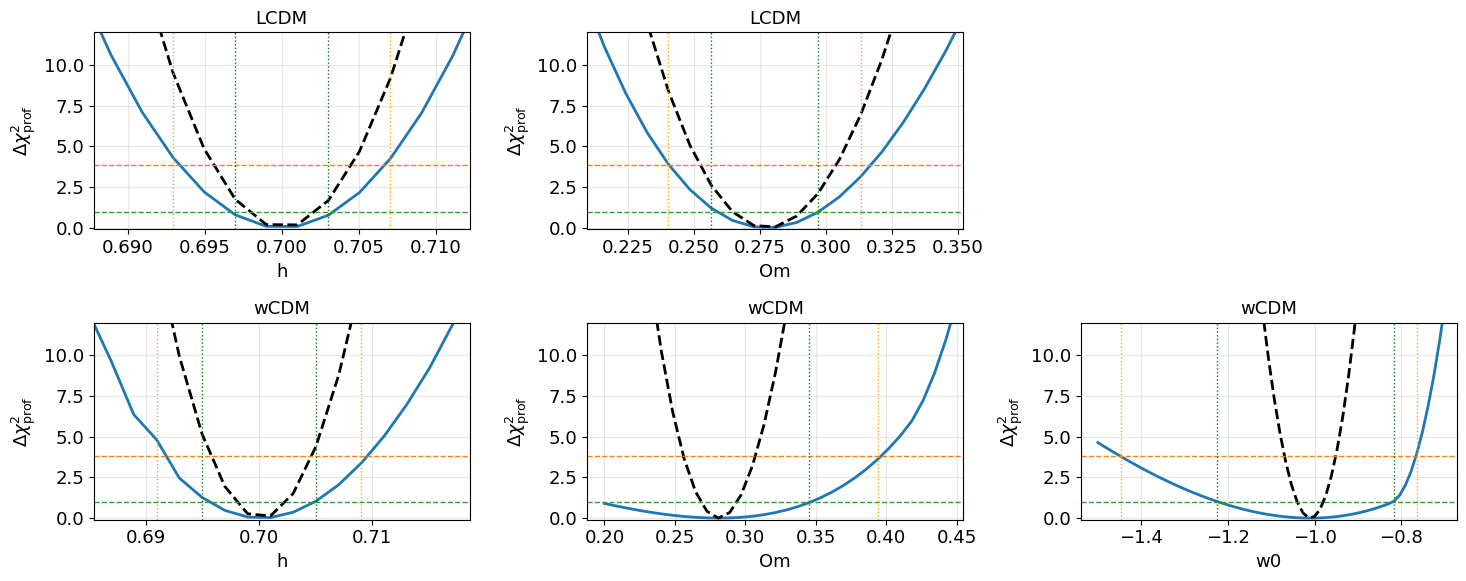

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15, 6))

for _model_ix, _model in enumerate(models):
    for par_ix, par_name in enumerate(par_names_dict[_model]):
        ax[_model_ix, par_ix].plot(
            profile_results[_model][par_name]['par_grid'],
            profile_results[_model][par_name]['dchi2'],
            lw=2,
        )
        ax[_model_ix, par_ix].plot(
            mle_results[_model][par_name]['par_grid'],
            mle_results[_model][par_name]['dchi2'],
            lw=2,
            ls='--',
            c='k',
        )
        ax[_model_ix, par_ix].axhline(
            delta_chi2_threshold_68_1dof,
            ls='--',
            c='tab:green',
            label=r'$1\sigma$ (1 par)',
        )
        ax[_model_ix, par_ix].axhline(
            delta_chi2_threshold_95_1dof,
            ls='--',
            c='tab:orange',
            label=r'$2\sigma$ (1 par)',
        )
        mask = profile_results[_model][par_name]['dchi2'] <= 12.0

        # this is just to zoom in on the relevant part of the plot
        if np.any(mask):
            x_lo = profile_results[_model][par_name]['par_grid'][mask].min()
            x_hi = profile_results[_model][par_name]['par_grid'][mask].max()
            pad = 0.05 * (x_hi - x_lo)
            ax[_model_ix, par_ix].set_xlim(x_lo - pad, x_hi + pad)
        ax[_model_ix, par_ix].set_ylim(-0.1, 12)

        ax[_model_ix, par_ix].axvline(
            ci_simple[_model][par_name]['levels']['68']['left'], ls=':', c='green'
        )
        ax[_model_ix, par_ix].axvline(
            ci_simple[_model][par_name]['levels']['68']['right'], ls=':', c='green'
        )
        ax[_model_ix, par_ix].axvline(
            ci_simple[_model][par_name]['levels']['95']['left'], ls=':', c='orange'
        )
        ax[_model_ix, par_ix].axvline(
            ci_simple[_model][par_name]['levels']['95']['right'], ls=':', c='orange'
        )
        ax[_model_ix, par_ix].set_xlabel(par_name)
        ax[_model_ix, par_ix].set_ylabel(r'$\Delta\chi^2_{\mathrm{prof}}$')
        ax[_model_ix, par_ix].set_title(_model)
        ax[_model_ix, par_ix].grid(alpha=0.3)

fig.tight_layout()
ax[0, 2].axis('off')

### 4. Compute GoF and p-values; check whether the models can be rejected at a given threshold (e.g., 5%)
This step is easier; recover the $\chi^2$ value at $\theta_{MLE}$ (you computed it before to get $\Delta\chi^2$) and compute the p-value from the CDF as
$$p = P(\chi^2 \geq  \chi^2_{min} | H_0) = \int^{\infty}_{\chi^2_{min}} \text {pdf}(\chi^2|H_0)\text d \chi^2 = 1-CDF(\chi^2_{min})$$
Remember: in this case $\chi^2_{min}$ follows a a $\chi^2_\nu$ distribution with $\nu = N_{data}-N_{params}$ degrees of freedom (dof).\
You can then test the null hypothesis (the model is true) against the alternative (the model is not true) by comparing the p-value with a threshold $\alpha$ (e.g., 0.05)

Being $\alpha$ the established threshold for rejecting $H_0$ (usually 0.05, or 5%):
* if $p > \alpha$, $H_0$ is not rejected at $(1-\alpha)$ "confidence"
* if $p < \alpha$, $H_0$ is rejected at $(1-\alpha)$ "confidence"


LCDM
chi2:		 562.23
dof:		 578.00
chi2/dof:	 0.973
p-value = 0.673 > 0.05 - the null hypothesis (the LCDM model) cannot be rejected

wCDM
chi2:		 562.22
dof:		 577.00
chi2/dof:	 0.974
p-value = 0.662 > 0.05 - the null hypothesis (the wCDM model) cannot be rejected


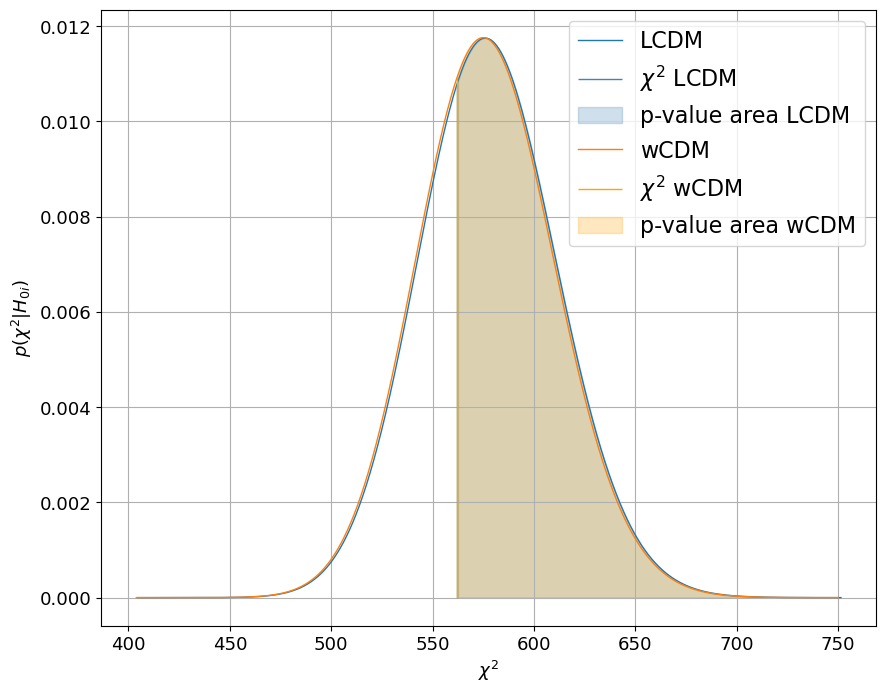

In [ ]:
plt.figure(figsize=(10, 8))
for _model in models:
    dof = N_obs - len(par_names_dict[_model])
    model_pred_at_mle = model_prediction(z_obs, theta_mle_dict[_model], _model)
    chi2_min = chi2_func(model_pred_at_mle, y_obs, inv_data_cov)
    pval = 1 - stats.chi2.cdf(chi2_min, dof)

    print(f'\n{_model}')
    print(f'chi2:\t\t {chi2_min:.2f}')
    print(f'dof:\t\t {dof:.2f}')
    print(f'chi2/dof:\t {chi2_min / dof:.3f}')
    if pval > p_val_threshold:
        print(
            f'p-value = {pval:.3f} > {p_val_threshold} - the null hypothesis (the {_model} model) cannot be rejected'
        )
    else:
        print(
            f'p-value = {pval:.3f} <= {p_val_threshold} - the null hypothesis (the {_model} model) can be rejected'
        )

    # plot chi2 pdf, chi2_min and p-value area
    chi2_grid = np.linspace(dof - 0.3 * dof, dof + 0.3 * dof, 1000)

    plt.plot(chi2_grid, stats.chi2(dof).pdf(chi2_grid), label=_model)
    plt.vlines(
        chi2_min,
        0,
        stats.chi2(dof).pdf(chi2_min),
        label=r'$\chi^2$ %s' % _model,
        color='steelblue' if _model == 'LCDM' else 'orange',
    )
    pdf = stats.chi2(dof).pdf(chi2_grid)
    mask = chi2_grid >= chi2_min

    # put this outside the loop as the chi2_min values for the two models are very close)
    plt.fill_between(
        chi2_grid[mask],
        pdf[mask],
        0,
        alpha=0.25,
        color='steelblue' if _model == 'LCDM' else 'orange',
        label=rf'p-value area {_model}',
    )


plt.legend(prop={'size': 16})
plt.xlabel(r'$\chi^2$')
plt.ylabel(r'$p(\chi^2|H_{0i})$')
plt.grid()


---

# Part 2 - Bayesian parameter inference

Now we turn to a Bayesian approach for parameter estimation and model selection; the posterior distribution of the parameters given the data is given by Bayes' theorem:

$$p(\boldsymbol\theta | \text {data}) = \dfrac{p(\text {data}|\boldsymbol\theta)p(\boldsymbol \theta)}   {p(\text{data})}  $$

This is what we need to sample.\ 
We will do it with the emcee and nautilus packages, which implement MH [on steroids] and the nested sampling algorithm respectively.


We use the $\tt {emcee}$ [link](https://emcee.readthedocs.io/en/stable/) Python package for the sampling process, with 2000 steps and 10 independent walkers starting from the best-fit values obtained by minimizing the NLL, with a small random deviation from such position for each walker. We discard the initial 10% of the points as burn-in

### 1. Define priors and posterior
This is required by emcee but not by Nautilus; remember that we defined the ln_likelihood, so it's convenient to define also the ln_prior. For the flat case, what is its expression? And for the Gaussian case? The (ln)posterior is trivial.\
Let's stert with flat and relatively broad priors, so as to be data-dominated.



In [ ]:
def ln_prior(theta, model):
    if model == 'LCDM':
        h, Om = theta
    elif model == 'wCDM':
        h, Om, w0 = theta

    ln_prior_val = 0.0

    if prior_type == 'flat':
        for param, param_name in zip(theta, par_names_dict[model]):
            # if outside the prior range, prior is 0 (and log is -inf)
            if (
                param < prior_ranges[param_name][0]
                or param > prior_ranges[param_name][1]
            ):
                return -np.inf
            # otherwise it's 1/delta, where delta is the width of the prior range
            else:
                delta = prior_ranges[param_name][1] - prior_ranges[param_name][0]
                ln_prior_val += np.log(1 / delta)

    # TODO remove this?
    ####################### GAUSSIAN PRIORS ######################
    # from eBoss 2020: https://www.sdss.org/science/cosmology-results-from-eboss/
    elif prior_type == 'gauss':
        if model == 'LCDM':
            mu = theta_fid['h']
            sigma = 0.003  # h
            ln_prior_val += (
                np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                - 0.5 * (h - mu) ** 2 / sigma**2
            )

            mu = theta_fid['Om']
            sigma = 0.004  # Om
            if Om <= 0:
                return -np.inf
            else:
                ln_prior_val += (
                    np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                    - 0.5 * (Om - mu) ** 2 / sigma**2
                )

        elif model == 'wCDM':
            mu = theta_fid['h']
            sigma = 0.007  # h
            ln_prior_val += (
                np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                - 0.5 * (h - mu) ** 2 / sigma**2
            )

            mu = theta_fid['Om']
            sigma = 0.006  # Om
            if Om <= 0:
                return -np.inf
            else:
                ln_prior_val += (
                    np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                    - 0.5 * (Om - mu) ** 2 / sigma**2
                )

            mu = theta_fid['w0']
            sigma = 0.02  # w0
            ln_prior_val += (
                np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                - 0.5 * (w0 - mu) ** 2 / sigma**2
            )
    ### end of gaussian priors definition
    return ln_prior_val


def ln_posterior(theta, data, model):
    # if outside the prior range, don't bother computing the likelihood,
    # just return -inf for the log posterior
    lp = ln_prior(theta, model)
    if not np.isfinite(lp):
        return -np.inf
    return ln_likelihood(theta, data, model) + lp


### 2. Run emcee

For emcee, you can play with the number of steps and walkers, and the initial positions of the walkers (e.g., starting from the best-fit values obtained by minimizing the NLL, with a small random deviation from such position for each walker)


The run can be executed in parallel by doing (works on linux and macOS)

```
ctx = mp.get_context('fork')  # context manager for multiprocessing
with ctx.Pool(processes=n_cpu) as pool:
    sampler = emcee.EnsembleSampler(
        Nwalkers,
        ndim,
        ln_posterior,
        args=(data, _model),
        pool=pool,
    )
    sampler.run_mcmc(theta_0, Nsteps, progress=True)
```

In [ ]:
burn_in_steps = int(Nsteps * burn_in_fraction)

trace_dict_emcee = {}

n_cpu = min(12, mp.cpu_count())
ctx = mp.get_context('fork')  # context manager for multiprocessing

for _model in models:
    fraction = 0.1
    theta_mle = theta_mle_dict[_model]
    ndim = theta_mle.size
    if _model == 'LCDM':
        theta_0 = np.asarray(
            [
                theta_mle
                + [
                    np.random.uniform(
                        -fraction * theta_mle[0], fraction * theta_mle[0]
                    ),
                    np.random.uniform(
                        -fraction * theta_mle[1], fraction * theta_mle[1]
                    ),
                ]
                for i in range(Nwalkers)
            ]
        )
    elif _model == 'wCDM':
        theta_0 = np.asarray(
            [
                theta_mle
                + [
                    np.random.uniform(
                        -fraction * theta_mle[0], fraction * theta_mle[0]
                    ),
                    np.random.uniform(
                        -fraction * theta_mle[1], fraction * theta_mle[1]
                    ),
                    np.random.uniform(
                        # -fraction * theta_mle[2], fraction * theta_mle[2]
                        -fraction * np.abs(theta_mle[2]),
                        fraction * np.abs(theta_mle[2]),
                    ),
                ]
                for i in range(Nwalkers)
            ]
        )

    with ctx.Pool(processes=n_cpu) as pool:
        sampler = emcee.EnsembleSampler(
            Nwalkers,
            ndim,
            ln_posterior,
            args=(data, _model),
            pool=pool,
        )
        sampler.run_mcmc(theta_0, Nsteps, progress=True)

    trace_dict_emcee[_model] = sampler.chain[:, burn_in_steps:, :].reshape(-1, ndim)

100%|██████████| 2000/2000 [00:40<00:00, 49.49it/s]


Save chains if you want

In [ ]:
for _model in models:
    np.save(
        f'{root}/output/trace_{_model}_steps_{Nsteps}_walkers_{Nwalkers}.npy',
        trace_dict_emcee[_model],
    )

### 3. Compute expectation values, standard deviations, parameter covariance and probability content of mean +/- std from the chains
* The first two steps are straightforward 
* For the third, you can use np.cov
* For the fourth, remember that once we have a chain we can integrate approximately by summing over the samples!
$$\int f(x) dx \approx \frac{1}{N} \sum_{i=1}^{N} f(x_i)$$
Bonus: you can also compute the intervals containing a given percentage of the probability (e.g., 68 and 95 percentiles) by looking at the quantiles of the distribution of the samples in the chain (use np.quantile)

In [ ]:
means_dict = {'LCDM': [], 'wCDM': []}
sigmas_dict = {'LCDM': [], 'wCDM': []}
probs_dict = {'LCDM': [], 'wCDM': []}
probs_dict2 = {'LCDM': [], 'wCDM': []}
covs_dict = {}


def central_quantile_interval(samples, q=0.68):
    """
        Central interval containing fraction q of
    samples.
        Example: q=0.68 -> [16th, 84th]
    percentiles.
    """
    alpha = (1.0 - q) / 2.0
    lo = np.quantile(samples, alpha)
    hi = np.quantile(samples, 1.0 - alpha)
    return lo, hi


def prob_in_interval(samples, lo, hi):
    return np.mean((samples >= lo) & (samples <= hi))


for _model in models:
    print(f'\n--------------------- {_model} -------------------------------------\n')

    theta_mle = theta_mle_dict[_model]
    ndim = theta_mle.size
    trace = trace_dict_emcee[_model]

    for param_index in range(ndim):
        mean = np.mean(trace[:, param_index])
        sigma = np.std(trace[:, param_index])

        # the prob is the integral, but MCMC samples allow to approximate it with the sum!
        prob_1sigma = np.mean(
            (trace[:, param_index] >= mean - sigma)
            & (trace[:, param_index] <= mean + sigma)
        )

        means_dict[_model].append(mean)
        sigmas_dict[_model].append(sigma)
        probs_dict[_model].append(prob_1sigma)

        # usage for one parameter chain:
        samples = trace[:, param_index]  # MCMC samples for that parameter
        q = 0.68  # user-chosen quantile
        lo, hi = central_quantile_interval(samples, q=q)
        p_est = prob_in_interval(samples, lo, hi)
        print(f'{q * 100:.1f}% central interval: [{lo:.6g}, {hi:.6g}]')

    # compute parameter's covariance
    # each row is a variable, each column an observation
    cov = np.cov(trace.T, bias=True)
    covs_dict[_model] = cov

    # sanity check: diagonal of covariance should be the variances
    assert np.allclose(
        np.diag(cov), np.array(sigmas_dict[_model]) ** 2, atol=0, rtol=1e-5
    )

    for param_index in range(ndim):
        print(
            f'{par_names_dict[_model][param_index]}: {means_dict[_model][param_index]:.5f} +/- {sigmas_dict[_model][param_index]:.5f} at prob = {probs_dict[_model][param_index]:.5f}'
        )


--------------------- LCDM -------------------------------------

68.0% central interval: [0.696342, 0.703247]
68.0% central interval: [0.259176, 0.29754]
h: 0.69980 +/- 0.00345 at prob = 0.68025
Om: 0.27837 +/- 0.01957 at prob = 0.69144

--------------------- wCDM -------------------------------------

68.0% central interval: [0.695396, 0.704729]
68.0% central interval: [0.200021, 0.345203]
68.0% central interval: [-1.21119, -0.818997]
h: 0.69994 +/- 0.00468 at prob = 0.68350
Om: 0.27429 +/- 0.07220 at prob = 0.67931
w0: -1.02190 +/- 0.19045 at prob = 0.66506


### 4. Produce a trace plot and check that the chains don't have pathologic behaviour.
Removing a burn-in phase should not be necessary, as we are starting from theta_MLE. You can check what happens if you start from a different position.\
Overplot the previously computed best-fit values and credible intervals to check that they are consistent with the chain distribution.

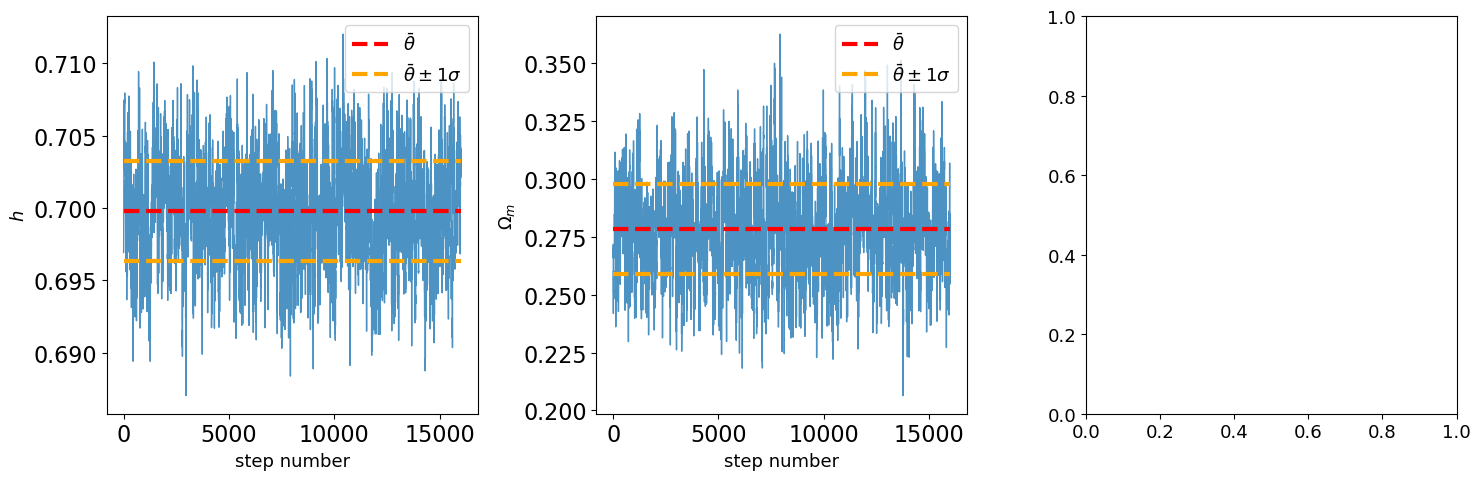

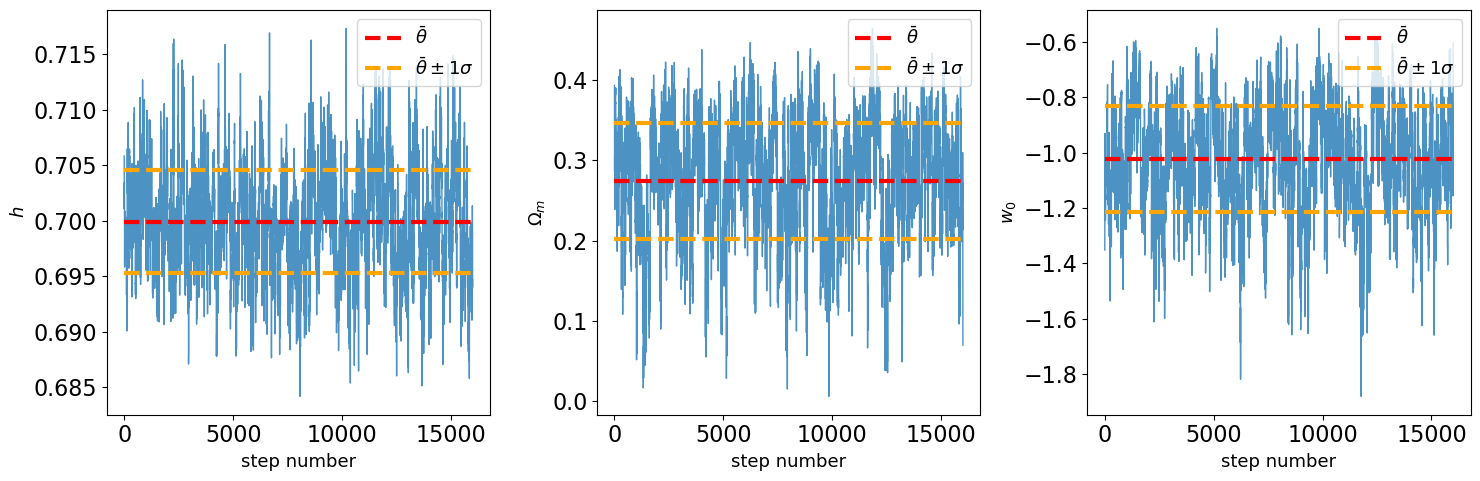

In [ ]:
for _model in models:
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
    trace = trace_dict_emcee[_model]
    par_names = par_names_dict[_model]
    par_names_tex = par_names_tex_dict[_model]

    for par_ix, (ax, par_name, ylabel) in enumerate(
        zip(axes, par_names, par_names_tex)
    ):
        ax.plot(range(trace.shape[0]), trace[:, par_ix], zorder=1, alpha=0.8)
        ax.set_xlabel('step number')
        ax.set_ylabel(ylabel)

        ax.hlines(
            means_dict[_model][par_ix],
            0,
            trace.shape[0],
            linestyles='dashed',
            color='red',
            zorder=2,
            label=r'$\bar{\theta}$',
            linewidth=3,
        )
        ax.hlines(
            means_dict[_model][par_ix] + sigmas_dict[_model][par_ix],
            0,
            trace.shape[0],
            linestyles='dashed',
            color='orange',
            zorder=2,
            label=r'$\bar{\theta} \pm 1\sigma$',
            linewidth=3,
        )
        ax.hlines(
            means_dict[_model][par_ix] - sigmas_dict[_model][par_ix],
            0,
            trace.shape[0],
            linestyles='dashed',
            color='orange',
            zorder=2,
            linewidth=3,
        )

        ax.legend(loc='upper right')
        ax.tick_params(labelsize=16)

        if _model == 'LCDM' and par_ix == 2:
            ax.axis('off')

    fig.tight_layout()

### 5. Make a corner plot with `corner`
This package is a bit old, but it's still widely used and does the at showing things the way they are, without smoothing
You can overplot the best-fit values from the MLE to check the consistency of the two approaches

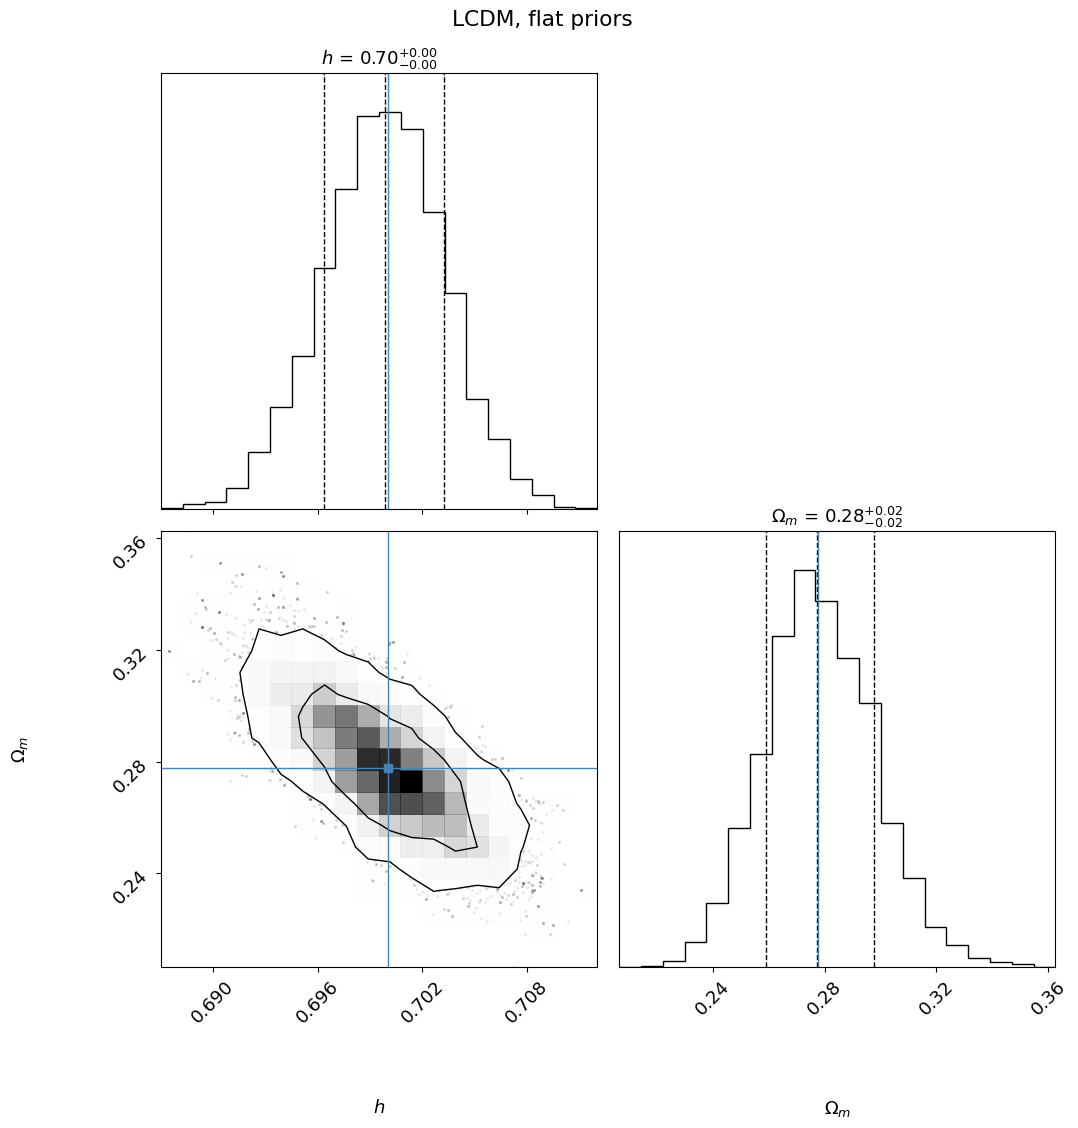

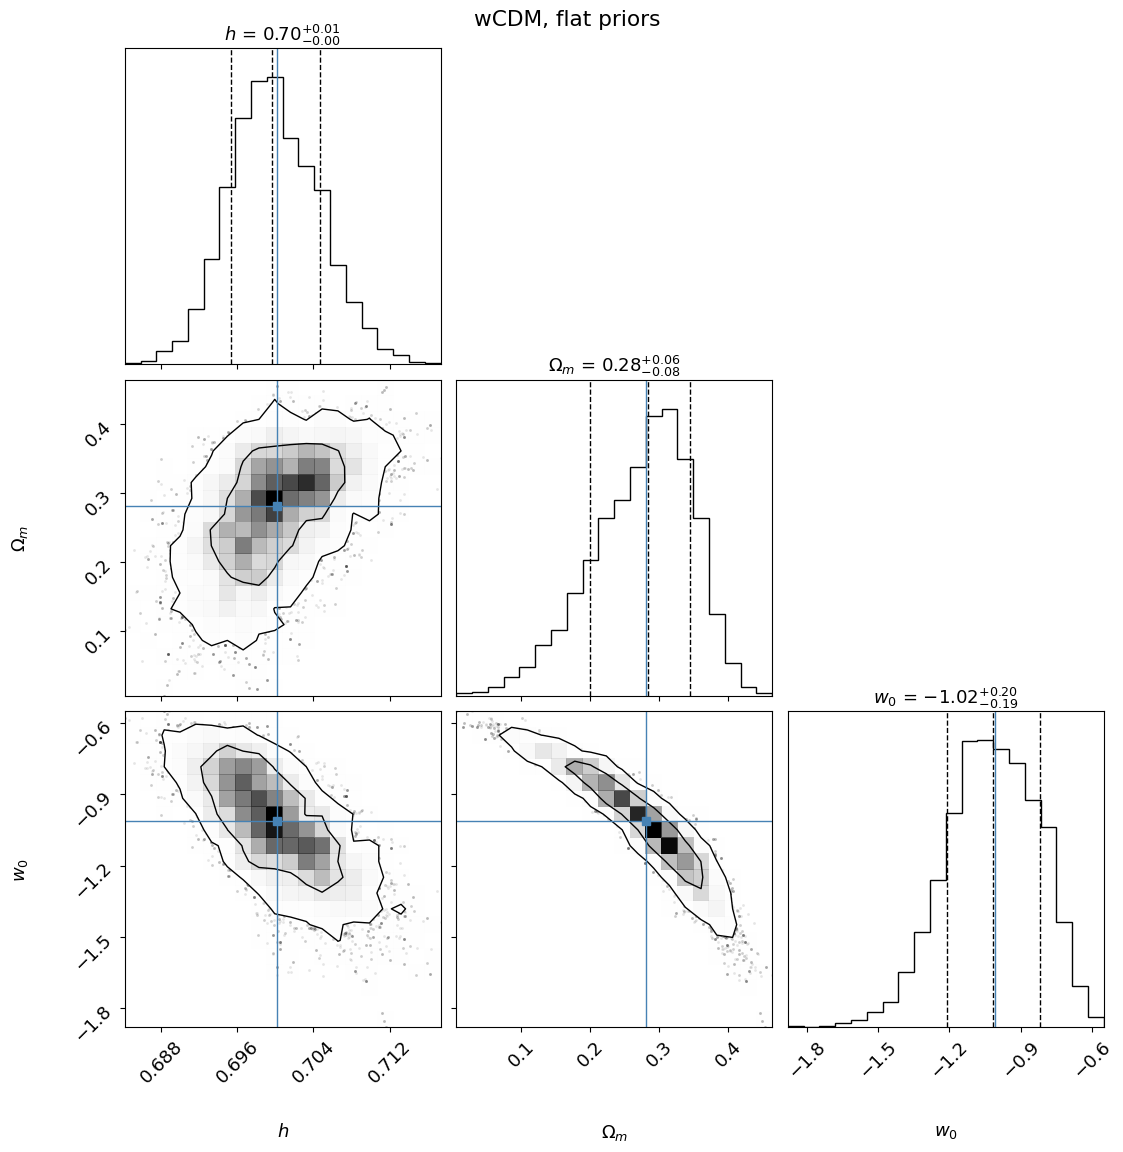

In [ ]:
for _model in models:
    fig = corner.corner(
        trace_dict_emcee[_model],
        quantiles=[0.16, 0.5, 0.84],  # meaning: x* where p(x<x*) = 16, 50, 84%
        labels=par_names_tex_dict[_model],
        truths=theta_mle_dict[_model],
        plot_contours=True,
        levels=(0.68, 0.95),
        show_titles=True,
    )
    fig.suptitle(f'{_model}, {prior_type} priors')
    fig.set_size_inches(12, 12)

### 6. Make a corner plot with `getdist`
This is a more modern package, which also allows to smooth the contours with KDEs. You can overplot the best-fit values from the MLE to check the consistency of the two approaches


Removed no burn in
Removed no burn in


Text(0.5, 0.98, 'LCDM vs wCDM, flat priors')

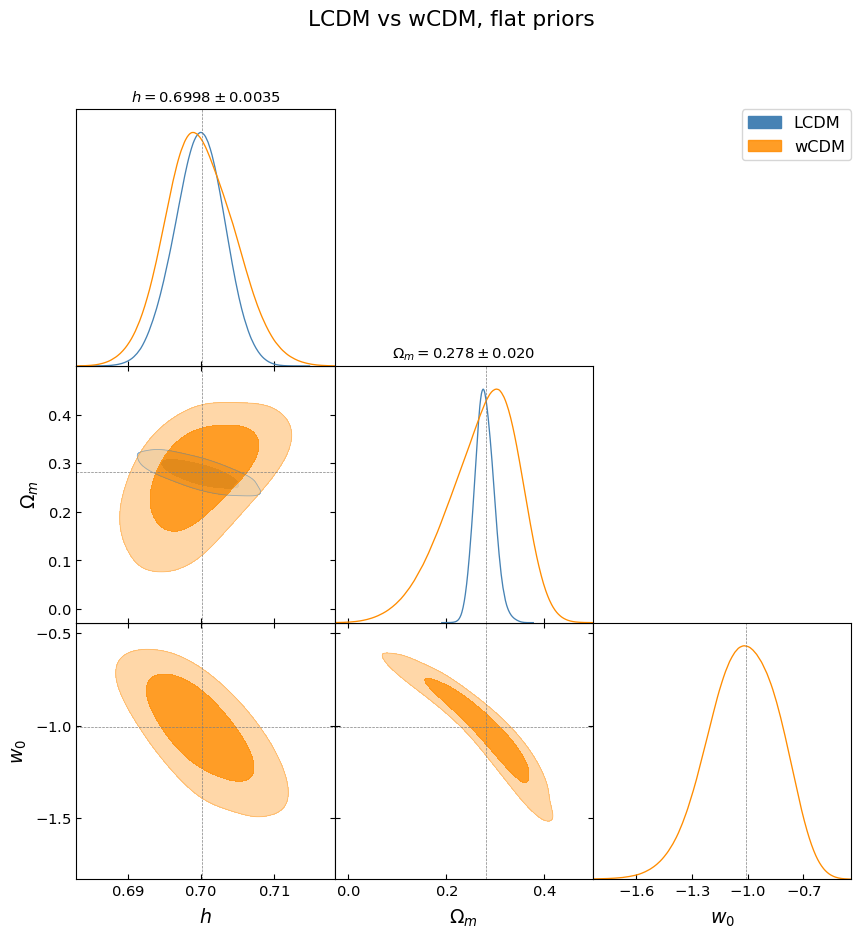

In [ ]:
from getdist import plots, MCSamples

gd_emcee_samples_dict = {}

for _model in models:
    gd_labels = [label.replace('$', '') for label in par_names_tex_dict[_model]]
    gd_names = par_names_dict[_model]

    gd_emcee_samples_dict[_model] = MCSamples(
        samples=trace_dict_emcee[_model],
        names=gd_names,
        labels=gd_labels,
        name_tag=f'{_model}_emcee',
    )
    # gd_emcee_samples_dict[_model].updateSettings({'contours': [0.68, 0.95]})

# Overlay LCDM and wCDM on shared parameters only
g = plots.get_subplot_plotter(width_inch=10)
g.triangle_plot(
    [gd_emcee_samples_dict['LCDM'], gd_emcee_samples_dict['wCDM']],
    ['h', 'Om', 'w0'],
    filled=True,
    contour_colors=['steelblue', 'darkorange'],
    legend_labels=['LCDM', 'wCDM'],
    markers=theta_mle_dict['wCDM'],
    title_limit=1,
)
g.fig.suptitle(f'LCDM vs wCDM, {prior_type} priors')

### 7. Plot best-fit curves and residuals
No appreciable difference between the two models, plot just LCDM. This simply to visually inspect the bes-fit line and to check whether the residuals show any unwanted trend.

/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_43880/59516870.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(prop={'size': 16})
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_43880/59516870.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend(prop={'size': 16})


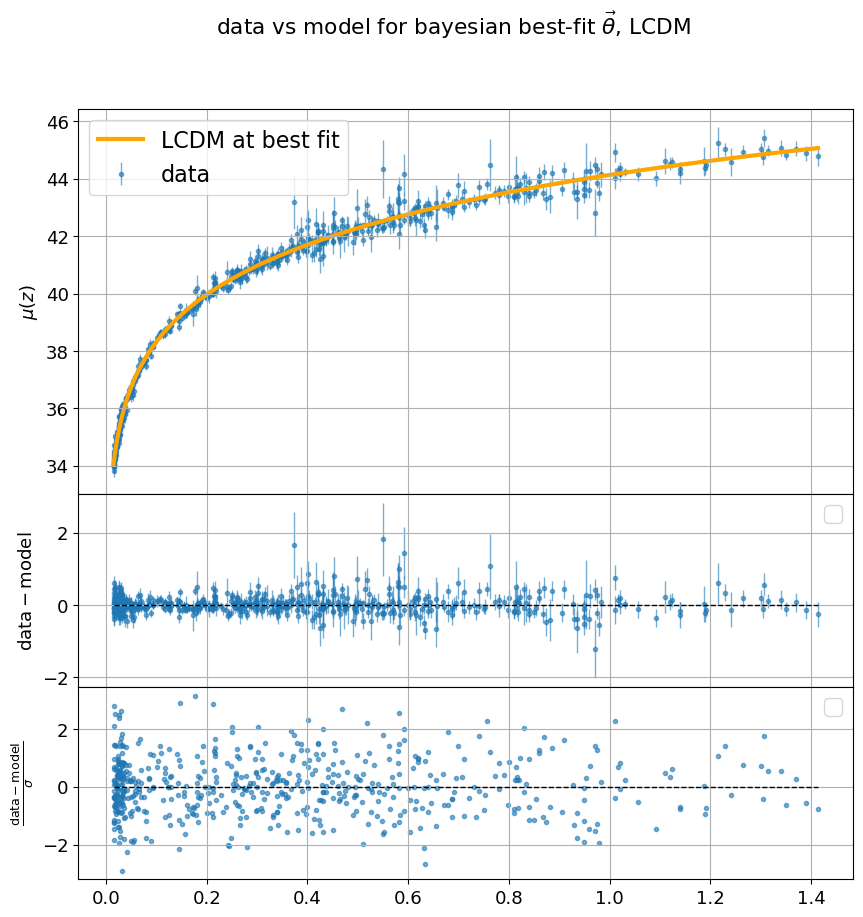

In [ ]:
_model = 'LCDM'

theta_best_fit = means_dict[_model]

# sort the data
data_union = data_union[np.argsort(data_union[:, 1])]
z_obs = data_union[:, 1]
y_obs = data_union[:, 2]
sigma_y = data_union[:, 3]

fig, axs = plt.subplots(
    3,
    height_ratios=[2, 1, 1],
    sharex=True,
    gridspec_kw={'hspace': 0.0},
)
fig.suptitle('data vs model for bayesian best-fit $\\vec{\\theta}$, %s' % _model)
fig.set_size_inches(10, 10)

axs[0].errorbar(z_obs, y_obs, yerr=sigma_y, fmt='.', alpha=0.6, label='data', zorder=1)
axs[0].plot(
    z_obs,
    model_prediction(z_obs, theta_best_fit, _model),
    label=_model + ' at best fit',
    color='orange',
    linewidth=3,
    zorder=1.5,
)
axs[1].errorbar(
    z_obs,
    y_obs - model_prediction(z_obs, theta_best_fit, _model),
    yerr=sigma_y,
    fmt='.',
    alpha=0.6,
    zorder=1,
)
axs[1].hlines(0, z_obs.min(), z_obs.max(), color='k', ls='--', zorder=2, linewidth=1)

axs[2].plot(
    z_obs,
    (y_obs - model_prediction(z_obs, theta_best_fit, _model)) / sigma_y,
    ls='',
    marker='.',
    alpha=0.6,
    zorder=1,
)
axs[2].hlines(0, z_obs.min(), z_obs.max(), color='k', ls='--', zorder=2, linewidth=1)

axs[0].set_ylabel(r'$\mu(z)$')
axs[1].set_ylabel(r'$\text{data} - \text{model}$')
axs[2].set_ylabel(r'$\frac{\text{data} - \text{model}}{\sigma}$')
axs[1].set_xlabel(r'$z$')
axs[0].grid()
axs[1].grid()
axs[2].grid()
axs[0].legend(prop={'size': 16})
axs[1].legend(prop={'size': 16})
axs[2].legend(prop={'size': 16})

In [ ]:
assert False, 'stop here'

AssertionError: stop here

# Bayesian model selection
In order to select the best model we compute the odds ratio

$$O_{12} = \dfrac{p(M_1|\text{data})}{p(M_2|\text{data})}=\dfrac{p(\text{data}|M_1)P(M_1)}{p(\text{data}|M_2)P(M_2)}=\dfrac{\int p(\text{data}|M_1,\boldsymbol\theta_1)p(\boldsymbol\theta_1|M_1)\text{d}\boldsymbol\theta_1}{\int p(\text{data}|M_2,\boldsymbol\theta_2)p(\boldsymbol\theta_2|M_2)\text{d}\boldsymbol\theta_2}\dfrac{p(M_1)}{p(M_2)}$$

which is simply the ratio of the posterior distributions, marginalized over the parameters of the models, folded with the prior probabilities on the different models (which we consider equal to each other).


Models with more parameters will be penalized with respect to models with fewer parameters, because the larger the number of parameters the more spread the prior will have with respect to the likelihood.


Already in 3-dimensional parameter space (for model wCDM) the computation takes a very long time. We therefore implement a routine to integrate the function with a simple random sampling of the posterior over the prior domain, exploiting the relation

$$\int f (\boldsymbol x) \text d \boldsymbol x \simeq \prod_{i=1}^d (b_i-a_i)\langle f(\boldsymbol x) \rangle =  \dfrac{\prod_{i=1}^d (b_i-a_i)}{N} \sum_{i=1}^N f(\boldsymbol x_i)$$

with $N$ number of sampling points, $d$ the number of dimensions of $\boldsymbol x$, and $(a_i, b_i)$ lower and upper bounds of the different priors' domains. The $x_i$ are, in our case, drawn from a uniform pdf.

### 6. Perform $\chi^2$-diff test to select between competing models XXX maybe also this?

A possible test to discriminate between the competing models is to check the likelihood ratio, computing $R=\dfrac{{\cal L}_{LCDM}(\text{data}|\hat{\boldsymbol{\theta}}_1)}{ {\cal L}_{wCDM}(\text{data}|\hat{\boldsymbol{\theta}}_2)}$. $\hat{\boldsymbol{\theta}}_i$ refer to the different best-fit parameters of the two models. This quantity is also a random variable following a $\chi^2$ distribution with $\nu_{LCDM}-\nu_{wCDM}$, which in this case equals to 1.

In [ ]:
"""print('null hypothesis:\t LCDM is the true model')
print('alternative hypothesis:\t wCDM is the true model')
print('')

# compute chi2 diff and diff in dofs
chi2_diff = compute_chi2('LCDM') - compute_chi2('wCDM')
dof_diff = dof_dict['LCDM'] - dof_dict['wCDM']

# compute p-value
p_value = quad(integrand, chi2_diff, np.inf, args=(dof_diff,))[0]
if p_value > p_val_threshold:
    print(
        f'p-value = {p_value:.3f} > {p_val_threshold} - the null hypothesis (LCDM is preferred over wCDM) cannot be rejected'
    )

# plot distribution and p-value
plt.figure(figsize=(10, 8))

x = np.linspace(0.0001, chi2_diff, 1000)
pdf_chi2 = stats.chi2(dof_diff).pdf(x)  # 1 dof
plt.plot(x, pdf_chi2, 'steelblue')


x = np.linspace(chi2_diff, 0.2, 1000)
pdf_chi2 = stats.chi2(dof_diff).pdf(x)
plt.plot(x, pdf_chi2, 'steelblue', label=r'$pdf(\Delta\chi^2)$')
plt.vlines(
    chi2_diff,
    0,
    stats.chi2(dof_diff).pdf(chi2_diff),
    colors='orange',
    label=r'$\Delta\chi^2$ measured',
)
plt.fill_between(x, 0, pdf_chi2, alpha=0.5, label='p-value')
plt.grid()
plt.legend(prop={'size': 16})
plt.xlabel(r'$\Delta\chi^2$')
plt.ylabel(r'$pdf(\Delta\chi^2)$')
"""

<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_43880/1104235630.py:26: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(x, pdf_chi2, 'steelblue', label=r'$pdf(\Delta\chi^2)$')


"print('null hypothesis:\t LCDM is the true model')\nprint('alternative hypothesis:\t wCDM is the true model')\nprint('')\n\n# compute chi2 diff and diff in dofs\nchi2_diff = compute_chi2('LCDM') - compute_chi2('wCDM')\ndof_diff = dof_dict['LCDM'] - dof_dict['wCDM']\n\n# compute p-value\np_value = quad(integrand, chi2_diff, np.inf, args=(dof_diff,))[0]\nif p_value > p_val_threshold:\n    print(\n        f'p-value = {p_value:.3f} > {p_val_threshold} - the null hypothesis (LCDM is preferred over wCDM) cannot be rejected'\n    )\n\n# plot distribution and p-value\nplt.figure(figsize=(10, 8))\n\nx = np.linspace(0.0001, chi2_diff, 1000)\npdf_chi2 = stats.chi2(dof_diff).pdf(x)  # 1 dof\nplt.plot(x, pdf_chi2, 'steelblue')\n\n\nx = np.linspace(chi2_diff, 0.2, 1000)\npdf_chi2 = stats.chi2(dof_diff).pdf(x)\nplt.plot(x, pdf_chi2, 'steelblue', label=r'$pdf(\\Delta\\chi^2)$')\nplt.vlines(\n    chi2_diff,\n    0,\n    stats.chi2(dof_diff).pdf(chi2_diff),\n    colors='orange',\n    label=r'$\\Delta\\

# Gaussian priors XXX
We adopt narrow gaussian prior distribution to check how the result change with more restrictive prior knowledge

# Nested sampling with nautilus (flat priors)


### Define flat priors and likelihood for nautilus
We use the same flat priors adopted above with `emcee` 

In [ ]:
from nautilus import Prior, Sampler


def build_nautilus_prior(model):
    prior = Prior()
    for param_name in par_names_dict[model]:
        prior.add_parameter(
            param_name, dist=(prior_ranges[param_name][0], prior_ranges[param_name][1])
        )
    return prior


def ln_likelihood_nautilus(params, model):
    """Thin wrapper to adapt our ln_likelihood function to nautilus' expected input
    format (the biggest difference is that nautilus expects a dict of parameters,
    not an array)"""
    if model == 'LCDM':
        theta = [params['h'], params['Om']]
    elif model == 'wCDM':
        theta = [params['h'], params['Om'], params['w0']]
    else:
        raise ValueError(f'Unknown model: {model}')

    return ln_likelihood(theta, data, model)

### Sample LCDM with nautilus

In [ ]:
prior_LCDM = build_nautilus_prior('LCDM')

start = time.perf_counter()

with ctx.Pool(processes=n_cpu) as pool:
    sampler_nautilus_LCDM = Sampler(
        prior_LCDM,
        ln_likelihood_nautilus,
        likelihood_kwargs={'model': 'LCDM'},
        n_live=n_live,
        pool=pool,
        seed=seed,
    )
    sampler_nautilus_LCDM.run(verbose=True)

print(f'nautilus LCDM took {time.perf_counter() - start:.1f} seconds to run')

points_LCDM, log_w_LCDM, log_l_LCDM = sampler_nautilus_LCDM.posterior(
    return_as_dict=True
)
logZ_LCDM = sampler_nautilus_LCDM.log_z

print(f'LCDM: logZ = {logZ_LCDM:.3f}, n_eff = {sampler_nautilus_LCDM.n_eff:.1f}')

### Sample wCDM with nautilus


In [ ]:
prior_wCDM = build_nautilus_prior('wCDM')

start = time.perf_counter()

with ctx.Pool(processes=n_cpu) as pool:
    sampler_nautilus_wCDM = Sampler(
        prior_wCDM,
        ln_likelihood_nautilus,
        likelihood_kwargs={'model': 'wCDM'},
        n_live=n_live,
        pool=pool,
        seed=seed + 1,
    )
    sampler_nautilus_wCDM.run(verbose=True)

print(f'nautilus wCDM took {time.perf_counter() - start:.1f} seconds to run')

points_wCDM, log_w_wCDM, log_l_wCDM = sampler_nautilus_wCDM.posterior(
    return_as_dict=True
)
logZ_wCDM = sampler_nautilus_wCDM.log_z

print(f'wCDM: logZ = {logZ_wCDM:.3f}, n_eff = {sampler_nautilus_wCDM.n_eff:.1f}')

### Plot the results with getdist
Now use the getdist package to plot the results of our runs. getdist performs internally a Gaussian smoothing of the histograms of the samples, as well as computing the best-fit and confidence intervals ()

In [ ]:
gd_nautilus_samples_dict = {}
for _model in models:
    gd_labels = [label.replace('$', '') for label in par_names_tex_dict[_model]]
    par_names = par_names_dict[_model]

    if _model == 'LCDM':
        points = points_LCDM
        log_w = log_w_LCDM
    elif _model == 'wCDM':
        points = points_wCDM
        log_w = log_w_wCDM

    samples = np.column_stack([points[name] for name in par_names])
    weights = np.exp(log_w)

    gd_nautilus_samples_dict[_model] = MCSamples(
        samples=samples,
        weights=weights,
        names=par_names,
        labels=gd_labels,
    )

g.triangle_plot(
    [gd_nautilus_samples_dict['LCDM'], gd_nautilus_samples_dict['wCDM']],
    params=par_names,
    filled=True,
    legend_labels=['LCDM (nautilus)', 'wCDM (nautilus)'],
    markers=theta_mle_dict['wCDM'],
    title_limit=1,
)

NameError: name 'points_LCDM' is not defined

### Compare nautilus to emcee

In [ ]:
_model = 'wCDM'

g.triangle_plot(
    [gd_emcee_samples_dict[_model], gd_nautilus_samples_dict[_model]],
    params=par_names_dict[_model],
    filled=True,
    legend_labels=[f'emcee {_model}', f'nautilus {_model}'],
    title_limit=1,
)

## Bayesian model comparison
Now, perform a model comparison between LCDM and wCDM by computing the odds ratio $O_{12}$, which is the ratio of the evidences of the two models. 

1. Retrieve the logZ values for the different models from the Nautilus runs

2. Compare them as explained and quantify the strength of efidence using the Jeffrey's scale

In [ ]:
logB_LCDM_wCDM = logZ_LCDM - logZ_wCDM

if logB_LCDM_wCDM >= 0:
    preferred_model = 'LCDM'
    logB = logB_LCDM_wCDM
else:
    preferred_model = 'wCDM'
    logB = -logB_LCDM_wCDM

print(f'logZ_LCDM = {logZ_LCDM:.3f}')
print(f'logZ_wCDM = {logZ_wCDM:.3f}')
print(f'log Bayes factor (LCDM / wCDM) = {logB_LCDM_wCDM:.3f}')
print(f'Preferred model: {preferred_model}')

if logB < 1:
    strength = 'inconclusive'
elif logB < 2.5:
    strength = 'weak'
elif logB < 5:
    strength = 'moderate'
else:
    strength = 'strong'

print(f'Evidence strength: {strength}')


2. Compute the Savage-Dickey density ratio and check whether the results match

In [ ]:
# Savage-Dickey density ratio for the nested pair LCDM (w0 = -1) vs wCDM
w0_ref = -1.0
w0_min, w0_max = prior_ranges['w0']
if not (w0_min <= w0_ref <= w0_max):
    raise ValueError(
        f'w0_ref={w0_ref} is outside the prior support [{w0_min}, {w0_max}]'
    )

prior_density_w0 = 1.0 / (w0_max - w0_min)

w0_samples = np.asarray(points_wCDM['w0'], dtype=float)
weights_w0 = np.exp(log_w_wCDM - np.max(log_w_wCDM))
weights_w0 /= np.sum(weights_w0)
posterior_kde_w0 = stats.gaussian_kde(w0_samples, weights=weights_w0)
posterior_density_w0 = float(posterior_kde_w0.evaluate([w0_ref])[0])

B_SD_LCDM_wCDM = posterior_density_w0 / prior_density_w0
logB_SD_LCDM_wCDM = np.log(B_SD_LCDM_wCDM)

print(f'Savage-Dickey B(LCDM / wCDM) = {B_SD_LCDM_wCDM:.3f}')
print(f'Savage-Dickey logB(LCDM / wCDM) = {logB_SD_LCDM_wCDM:.3f}')
print(
    f'\u0394logB (Savage-Dickey - evidence) = {logB_SD_LCDM_wCDM - logB_LCDM_wCDM:.3f}'
)

3. Try rerunning playing around with the priors (shape/ranges) and see if the results change

# Fisher-matrix forecasts


In [ ]:
def numerical_jacobian(theta, model, eps_frac=1e-4):
    param_names = par_names_dict[model]
    theta = np.array(theta, dtype=float)
    n_params = len(theta)
    jac = np.zeros((z_obs.size, n_params))

    mu0 = model_prediction(z_obs, theta, model)

    for j, pname in enumerate(param_names):
        low, high = prior_ranges[pname]
        step = eps_frac * (high - low)

        theta_plus = theta.copy()
        theta_minus = theta.copy()

        if theta[j] - step < low:
            theta_plus[j] += step
            mu_plus = model_prediction(z_obs, theta_plus, model)
            jac[:, j] = (mu_plus - mu0) / step
        elif theta[j] + step > high:
            theta_minus[j] -= step
            mu_minus = model_prediction(z_obs, theta_minus, model)
            jac[:, j] = (mu0 - mu_minus) / step
        else:
            theta_plus[j] += step
            theta_minus[j] -= step
            mu_plus = model_prediction(z_obs, theta_plus, model)
            mu_minus = model_prediction(z_obs, theta_minus, model)
            jac[:, j] = (mu_plus - mu_minus) / (2.0 * step)

    return jac


## 2) Compute Fisher matrix


In [ ]:
def logw_to_prob(log_w):
    w = np.exp(log_w - np.max(log_w))
    return w / np.sum(w)


def nautilus_weighted_mean(points_dict, log_w, param_names):
    p = logw_to_prob(log_w)
    mean = np.array([np.sum(points_dict[name] * p) for name in param_names])
    return mean, p


def fisher_matrix(theta, model):
    J = numerical_jacobian(theta, model)
    inv_var = 1.0 / (sigma_y**2)
    return J.T @ (inv_var[:, None] * J)


nautilus_points = {'LCDM': points_LCDM, 'wCDM': points_wCDM}
nautilus_logw = {'LCDM': log_w_LCDM, 'wCDM': log_w_wCDM}

fisher_results = {}

for _model in ['LCDM', 'wCDM']:
    param_names = par_names_dict[_model]
    theta_fid, p = nautilus_weighted_mean(
        nautilus_points[_model], nautilus_logw[_model], param_names
    )

    F = fisher_matrix(theta_fid, _model)
    condF = np.linalg.cond(F)
    if np.isfinite(condF) and condF < 1e12:
        C = np.linalg.inv(F)
        inversion = 'inv'
    else:
        C = np.linalg.pinv(F)
        inversion = 'pinv'

    fisher_results[_model] = {
        'param_names': param_names,
        'theta_fid': theta_fid,
        'weights': p,
        'F': F,
        'C': C,
    }

    print(f'\n{_model}')
    print('theta_fid =', theta_fid)
    print('cond(F) =', condF, f'({inversion})')
    print('Fisher matrix =')
    print(F)
    print('Fisher sigmas =', np.sqrt(np.diag(C)))


## 3) Build getdist samples for nautilus and Fisher approximation


In [ ]:
label_map = {'h': 'h', 'Om': r'\Omega_m', 'w0': 'w_0'}

rng = np.random.default_rng(seed)
n_fisher_draws = 100000

getdist_fisher = {}
for _model in ['LCDM', 'wCDM']:
    param_names = fisher_results[_model]['param_names']
    labels = [label_map[p] for p in param_names]

    theta_fid = fisher_results[_model]['theta_fid']
    C = fisher_results[_model]['C']
    X_fisher = rng.multivariate_normal(theta_fid, C, size=n_fisher_draws)

    getdist_fisher[_model] = MCSamples(
        samples=X_fisher,
        names=param_names,
        labels=labels,
        name_tag=f'{_model}_fisher',
    )

## 4) Overlay FM results against nautilus results (getdist)


In [ ]:
for _model in ['LCDM', 'wCDM']:
    param_names = fisher_results[_model]['param_names']

    g = plots.get_subplot_plotter(width_inch=8)
    g.triangle_plot(
        [gd_nautilus_samples_dict[_model], getdist_fisher[_model]],
        param_names,
        filled=True,
        contour_colors=['steelblue', 'orange'],
        legend_labels=['nautilus', 'Fisher matrix'],
        title_limit=1,
    )
    g.fig.suptitle(f'{_model}: nautilus vs Fisher matrix', y=1.02)


## Posterior predictive checks (if there is time)